# Business Framing Analysis - Simplified
## Analisis Framing Bisnis: Delivery, Quality, dan Shipping Cost

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## Step 2: Load Data

In [2]:
data_path = './data/'

orders_df = pd.read_csv(data_path + 'olist_orders_dataset.csv')
order_items_df = pd.read_csv(data_path + 'olist_order_items_dataset.csv')
order_payments_df = pd.read_csv(data_path + 'olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv(data_path + 'olist_order_reviews_dataset.csv')

print(f"Orders: {orders_df.shape}")
print(f"Items: {order_items_df.shape}")
print(f"Payments: {order_payments_df.shape}")
print(f"Reviews: {order_reviews_df.shape}")

Orders: (99441, 8)
Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)


## Step 3: Convert Date Columns

In [3]:
date_cols = ['order_purchase_timestamp', 'order_delivered_carrier_date', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print("Date columns converted successfully")

Date columns converted successfully


## Step 4: Merge Datasets

In [4]:
# Aggregate items per order
items_agg = order_items_df.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()
items_agg.columns = ['order_id', 'total_price', 'total_freight']

# Aggregate reviews per order
reviews_agg = order_reviews_df.groupby('order_id')['review_score'].mean().reset_index()
reviews_agg.columns = ['order_id', 'avg_review_score']

# Merge everything
df = orders_df.merge(items_agg, on='order_id', how='left')
df = df.merge(reviews_agg, on='order_id', how='left')

print(f"Merged dataset: {df.shape}")

Merged dataset: (99441, 11)


## Step 5: Create Key Variables

In [5]:
# Delivery duration (days)
df['delivery_duration'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

# Delay: positive = late, negative = early
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# Timeliness status
df['timeliness_status'] = df['delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'Early' if x < 0 else 'On Time'
)

# Freight ratio
df['freight_ratio'] = df['total_freight'] / df['total_price']

# Low review flag (score <= 2)
df['low_review'] = (df['avg_review_score'] <= 2).astype(int)

print("Variables created successfully")
print(f"\nSample data:")
print(df[['order_id', 'delivery_duration', 'delay_days', 'timeliness_status', 'freight_ratio', 'avg_review_score']].head())

Variables created successfully

Sample data:
                           order_id  delivery_duration  delay_days  \
0  e481f51cbdc54678b7cc49136f2d6af7                6.0        -8.0   
1  53cdb2fc8bc7dce0b6741e2150273451               12.0        -6.0   
2  47770eb9100c2d0c44946d9cf07ec65d                9.0       -18.0   
3  949d5b44dbf5de918fe9c16f97b45f8a                9.0       -13.0   
4  ad21c59c0840e6cb83a9ceb5573f8159                1.0       -10.0   

  timeliness_status  freight_ratio  avg_review_score  
0             Early       0.290764               4.0  
1             Early       0.191744               4.0  
2             Early       0.120200               5.0  
3             Early       0.604444               5.0  
4             Early       0.438191               5.0  


## Step 6: Basic Statistics

In [6]:
print("=== DELIVERY FRAMING ===")
print(f"Average delivery duration: {df['delivery_duration'].mean():.2f} days")
print(f"Average delay: {df['delay_days'].mean():.2f} days")
print(f"\nTimeliness distribution:")
print(df['timeliness_status'].value_counts())

print("\n=== QUALITY FRAMING ===")
print(f"Average review score: {df['avg_review_score'].mean():.2f}")
print(f"Low review rate: {df['low_review'].mean()*100:.2f}%")

print("\n=== SHIPPING COST FRAMING ===")
print(f"Average freight ratio: {df['freight_ratio'].mean():.3f}")

=== DELIVERY FRAMING ===
Average delivery duration: 8.88 days
Average delay: -11.88 days

Timeliness distribution:
timeliness_status
Early      88649
Late        6535
On Time     4257
Name: count, dtype: int64

=== QUALITY FRAMING ===
Average review score: 4.09
Low review rate: 14.53%

=== SHIPPING COST FRAMING ===
Average freight ratio: 0.308


## Step 7: Hypothesis Testing - Delivery Impact on Reviews

In [7]:
# Filter valid data
valid_df = df[df['avg_review_score'].notna()]

# On-time vs Late reviews
ontime = valid_df[valid_df['timeliness_status'] == 'On Time']['avg_review_score']
late = valid_df[valid_df['timeliness_status'] == 'Late']['avg_review_score']

print("=== DELIVERY IMPACT ON REVIEWS ===")
print(f"On-time deliveries: {len(ontime)} orders, avg review: {ontime.mean():.3f}")
print(f"Late deliveries: {len(late)} orders, avg review: {late.mean():.3f}")

# T-test
t_stat, p_val = ttest_ind(ontime, late, equal_var=False)
print(f"\nT-test: t={t_stat:.3f}, p-value={p_val:.6f}")
print(f"Significant (α=0.05): {'Yes' if p_val < 0.05 else 'No'}")

=== DELIVERY IMPACT ON REVIEWS ===
On-time deliveries: 4123 orders, avg review: 2.462
Late deliveries: 6382 orders, avg review: 2.272

T-test: t=5.813, p-value=0.000000
Significant (α=0.05): Yes


## Step 8: Correlation Analysis

In [8]:
# Correlation: Delay vs Review Score
valid_data = df[['delay_days', 'avg_review_score', 'freight_ratio']].dropna()

corr_delay_review, p1 = pearsonr(valid_data['delay_days'], valid_data['avg_review_score'])
corr_freight_review, p2 = pearsonr(valid_data['freight_ratio'], valid_data['avg_review_score'])

print("=== CORRELATION ANALYSIS ===")
print(f"Delay vs Review Score: r={corr_delay_review:.3f}, p={p1:.6f}")
print(f"Freight Ratio vs Review Score: r={corr_freight_review:.3f}, p={p2:.6f}")

=== CORRELATION ANALYSIS ===
Delay vs Review Score: r=-0.267, p=0.000000
Freight Ratio vs Review Score: r=-0.024, p=0.000000


## Step 9: Monthly Trends

In [9]:
# Add month column
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Monthly stats
monthly = df.groupby('month').agg({
    'delay_days': 'mean',
    'avg_review_score': 'mean',
    'freight_ratio': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'order_count'})

print("=== MONTHLY TRENDS (First 6 months) ===")
print(monthly.head(6))

=== MONTHLY TRENDS (First 6 months) ===
         delay_days  avg_review_score  freight_ratio  order_count
month                                                            
2016-09   36.000000          1.000000       0.397799            4
2016-10  -36.659259          3.561129       0.284279          324
2016-12  -22.000000          5.000000       0.800000            1
2017-01  -27.408000          4.062658       0.339426          800
2017-02  -19.195402          4.015837       0.336539         1780
2017-03  -12.327180          4.074596       0.316525         2682


## Step 10: Visualizations

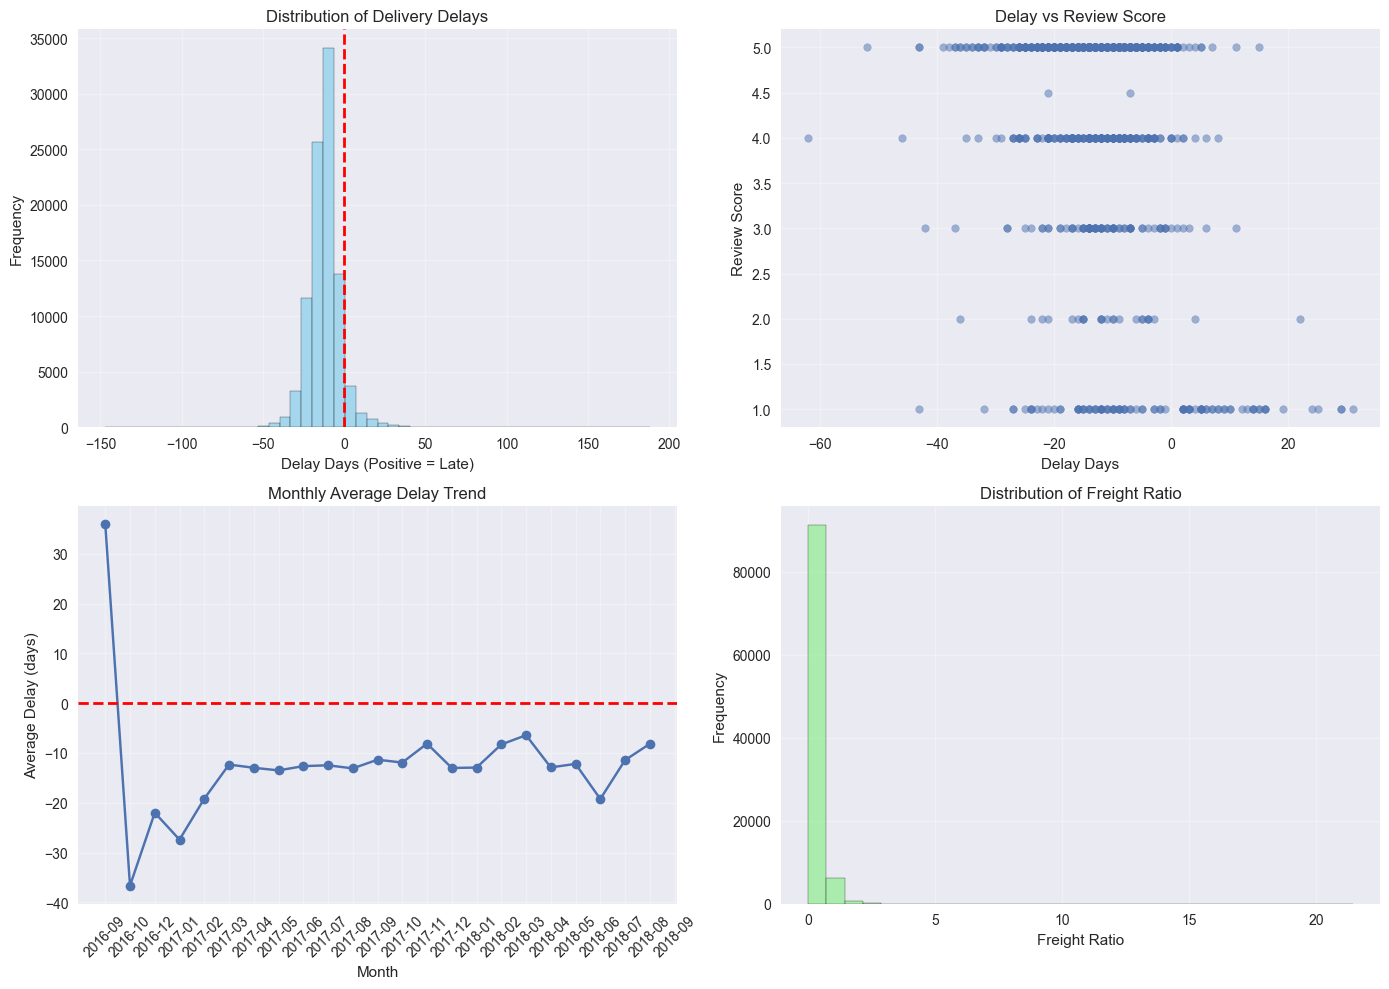

In [10]:
# Plot 1: Delay Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of delays
axes[0, 0].hist(df['delay_days'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Distribution of Delivery Delays')
axes[0, 0].set_xlabel('Delay Days (Positive = Late)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Delay vs Review Score scatter
sample = df[df['avg_review_score'].notna()].sample(1000, random_state=42)
axes[0, 1].scatter(sample['delay_days'], sample['avg_review_score'], alpha=0.5, s=30)
axes[0, 1].set_title('Delay vs Review Score')
axes[0, 1].set_xlabel('Delay Days')
axes[0, 1].set_ylabel('Review Score')
axes[0, 1].grid(True, alpha=0.3)

# Monthly delay trend
axes[1, 0].plot(monthly.index.astype(str), monthly['delay_days'], marker='o')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Monthly Average Delay Trend')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Delay (days)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Freight ratio distribution
axes[1, 1].hist(df['freight_ratio'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 1].set_title('Distribution of Freight Ratio')
axes[1, 1].set_xlabel('Freight Ratio')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 11: Summary & Recommendation

In [11]:
print("="*60)
print("SUMMARY & RECOMMENDATION")
print("="*60)

# Calculate impact metrics
late_rate = (df['timeliness_status'] == 'Late').mean() * 100
low_review_rate = df['low_review'].mean() * 100
avg_freight = df['freight_ratio'].mean() * 100

print(f"""
1. DELIVERY FRAMING:
   - Late delivery rate: {late_rate:.1f}%
   - Average delay: {df['delay_days'].mean():.1f} days
   - Impact on reviews: DELAYED orders have {ontime.mean() - late.mean():.2f} points LOWER review scores

2. QUALITY FRAMING:
   - Low review rate (score ≤ 2): {low_review_rate:.1f}%
   - Average review score: {df['avg_review_score'].mean():.2f}/5

3. SHIPPING COST FRAMING:
   - Average freight ratio: {avg_freight:.1f}% of product price

RECOMMENDATION:
Based on the analysis, DELIVERY FRAMING has the highest impact:
- Late deliveries significantly reduce customer satisfaction
- The correlation between delay and review score is significant
- Improving delivery timeliness should be the TOP PRIORITY
""")

SUMMARY & RECOMMENDATION

1. DELIVERY FRAMING:
   - Late delivery rate: 6.6%
   - Average delay: -11.9 days
   - Impact on reviews: DELAYED orders have 0.19 points LOWER review scores

2. QUALITY FRAMING:
   - Low review rate (score ≤ 2): 14.5%
   - Average review score: 4.09/5

3. SHIPPING COST FRAMING:
   - Average freight ratio: 30.8% of product price

RECOMMENDATION:
Based on the analysis, DELIVERY FRAMING has the highest impact:
- Late deliveries significantly reduce customer satisfaction
- The correlation between delay and review score is significant
- Improving delivery timeliness should be the TOP PRIORITY

